In [50]:
import pandas as pd

train_data = pd.read_csv('Data/final_train.csv', index_col=0)
test_data = pd.read_csv('Data/final_test.csv', index_col=0)

train_x, train_y = train_data.drop('SalePrice', axis=1), train_data['SalePrice']
test_x, test_y = test_data.drop('SalePrice', axis=1), test_data['SalePrice']

train_x

,Foundation_PConc,GarageType_Detchd,GarageType_Attchd,Exterior2nd_VinylSd,MSZoning_RM,Foundation_CBlock,Neighborhood_NAmes,MSZoning_RL,Exterior1st_VinylSd,SaleType_New,...,Bsmt_index,Garage_index,Condition_index,Living_Area,OpenSF,Luxury_index,Comf_idx,FullBath,LotFrontage,YearBuilt
741,True,False,True,False,False,False,False,True,False,False,...,5,6,60.000,35.628359,3.590896,3.875578,9.414997,0.911265,15.604698,1995
865,False,True,False,False,False,True,True,True,False,False,...,3,4,37.500,36.329019,0.000000,0.154925,13.298420,0.911265,26.535234,1949
339,True,False,True,False,False,False,False,True,False,True,...,7,6,30.000,42.542947,3.468843,5.547298,13.581823,1.712883,25.179280,2005
192,False,False,False,False,True,True,False,False,False,False,...,2,0,46.875,37.573278,5.672260,0.000000,17.129117,0.911265,36.667137,1912
203,False,False,True,False,False,True,True,True,False,False,...,4,5,15.000,34.079853,3.168412,4.371354,14.938750,0.911265,31.425563,1964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,True,False,True,False,False,False,True,False,False,False,...,7,6,60.000,34.165046,8.774702,4.159288,9.562460,1.712883,17.186882,1998
1185,False,True,False,True,False,True,True,True,True,False,...,6,4,17.500,33.420319,9.100719,4.004645,14.336896,0.911265,30.469668,1965
1167,True,False,True,True,False,False,False,True,True,False,...,9,5,10.000,36.102675,10.752007,4.472627,14.451533,1.712883,29.826615,2003
517,True,False,True,True,False,False,False,True,True,False,...,4,6,30.000,37.475508,7.784056,1.253723,14.874775,1.712883,31.108063,2004


## Matric Function

In [51]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

def metric(y_hat, y_true,features_shape):
    n,p = features_shape
    r2 = r2_score(y_true, y_hat)
    socres = {
        "MAE": mean_absolute_error(y_true, y_hat),
        "MSE": mean_squared_error(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R2": r2,
        "Adjusted R2":  1 - (1 - r2) * (n - 1) / (n - p - 1)
    }

    df_score = pd.DataFrame(socres.items(), columns=["Metric","Value"])

    return df_score

def judge(pipe, plot:bool = True):
    global train_x, train_y, test_x, test_y

    pipe.fit(train_x, train_y)
    train_pred = pipe.predict(train_x)
    test_pred = pipe.predict(test_x)

    train_score = metric(train_y, train_pred, train_x.shape)
    test_score = metric(test_y, test_pred, train_x.shape)

    fig,ax = plt.subplots(1,2, figsize=(10,5))
    ax = ax.flatten()

    sns.barplot(train_score, x='Metric', y='Value', ax=ax[0])
    ax[0].set_title('Train')

    sns.barplot(test_score, x='Metric', y='Value', ax=ax[1])
    ax[1].set_title('Test')

    return train_score, test_score

# Regression Models
In this particular example I will test linear regression, Ridge  and Random Forest Regressor with additional data scaling and feature selection

## Linear Regression Approach

In [52]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

def linear_objective(trial, X, y):
    n_features = X.shape[1]
    k = trial.suggest_int("selector__k", 1, n_features)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=k)),
        ('regressor', LinearRegression())
    ])

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    score = cross_val_score(
        pipe, X, y,
        cv=cv,
        scoring='neg_mean_squared_error'
    ).mean()

    return score

linear_study = optuna.create_study(direction='maximize')
linear_study.optimize(lambda trial: linear_objective(trial, train_x, train_y), n_trials=10, show_progress_bar=True)

linear_study.best_params

[I 2026-03-25 20:15:04,540] A new study created in memory with name: no-name-73331cf4-98f9-445f-aecf-e51c331d963c


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-25 20:15:04,686] Trial 0 finished with value: -1583781875.0587304 and parameters: {'selector__k': 16}. Best is trial 0 with value: -1583781875.0587304.
[I 2026-03-25 20:15:04,844] Trial 1 finished with value: -1877485631.3845093 and parameters: {'selector__k': 7}. Best is trial 0 with value: -1583781875.0587304.
[I 2026-03-25 20:15:04,981] Trial 2 finished with value: -1590140025.2714248 and parameters: {'selector__k': 15}. Best is trial 0 with value: -1583781875.0587304.
[I 2026-03-25 20:15:05,131] Trial 3 finished with value: -1551715532.7199318 and parameters: {'selector__k': 20}. Best is trial 3 with value: -1551715532.7199318.
[I 2026-03-25 20:15:05,275] Trial 4 finished with value: -1590140025.2714248 and parameters: {'selector__k': 15}. Best is trial 3 with value: -1551715532.7199318.
[I 2026-03-25 20:15:05,405] Trial 5 finished with value: -1648321548.9609911 and parameters: {'selector__k': 12}. Best is trial 3 with value: -1551715532.7199318.
[I 2026-03-25 20:15:05,

{'selector__k': 22}

,Metric,Value
0,MAE,2.684975e+04
1,MSE,1.789751e+09
2,RMSE,4.230545e+04
3,R2,6.228819e-01
4,Adjusted R2,6.146837e-01


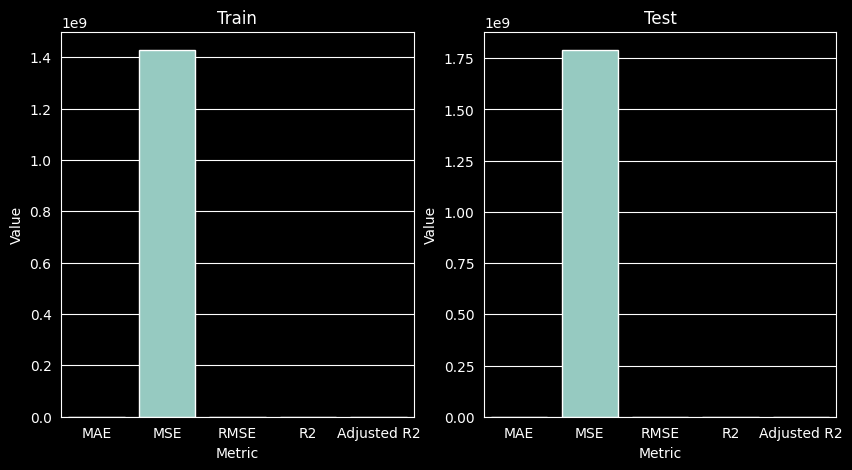

In [53]:
linear_pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(k=10)),
    ('regressor', LinearRegression())
])

linear_pipline.set_params(**linear_study.best_params)

_ , linear_score = judge(linear_pipline)

linear_score

# Ridge

In [54]:
from sklearn.linear_model import Ridge


def ridge_objective(trial, X, y):

    alpha = trial.suggest_float("regressor__alpha", 1e-4, 100.0, log=True)
    tol = trial.suggest_float("regressor__tol", 1e-4, 100.0, log=True)
    solver = trial.suggest_categorical("regressor__solver", ['svd', 'cholesky', 'lsqr'])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=alpha, tol=tol, solver=solver))
    ])

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    score = cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_squared_error').mean()

    return score

ridge_study = optuna.create_study(direction='maximize')
ridge_study.optimize( lambda trial: ridge_objective(trial, train_x, train_y), n_trials=5, show_progress_bar=True)

ridge_study.best_params

[I 2026-03-25 20:15:07,964] A new study created in memory with name: no-name-b8dd1622-9d02-4e84-8abd-7be22cfef014


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-25 20:15:08,168] Trial 0 finished with value: -1760353647.1307266 and parameters: {'regressor__alpha': 0.001230035699438867, 'regressor__tol': 0.13247427061104547, 'regressor__solver': 'lsqr'}. Best is trial 0 with value: -1760353647.1307266.
[I 2026-03-25 20:15:08,341] Trial 1 finished with value: -1506299153.5025241 and parameters: {'regressor__alpha': 53.21983199783881, 'regressor__tol': 97.17234415222734, 'regressor__solver': 'svd'}. Best is trial 1 with value: -1506299153.5025241.
[I 2026-03-25 20:15:08,489] Trial 2 finished with value: -1507253724.1248033 and parameters: {'regressor__alpha': 55.76946779665204, 'regressor__tol': 96.46199386419055, 'regressor__solver': 'svd'}. Best is trial 1 with value: -1506299153.5025241.
[I 2026-03-25 20:15:08,619] Trial 3 finished with value: -1493978237.0218363 and parameters: {'regressor__alpha': 2.35627171527065, 'regressor__tol': 0.08403270356829184, 'regressor__solver': 'cholesky'}. Best is trial 3 with value: -1493978237.02183

{'regressor__alpha': 0.14315599693743658,
 'regressor__tol': 0.00014335411218552546,
 'regressor__solver': 'cholesky'}

,Metric,Value
0,MAE,2.684680e+04
1,MSE,1.793901e+09
2,RMSE,4.235447e+04
3,R2,6.261090e-01
4,Adjusted R2,6.179809e-01


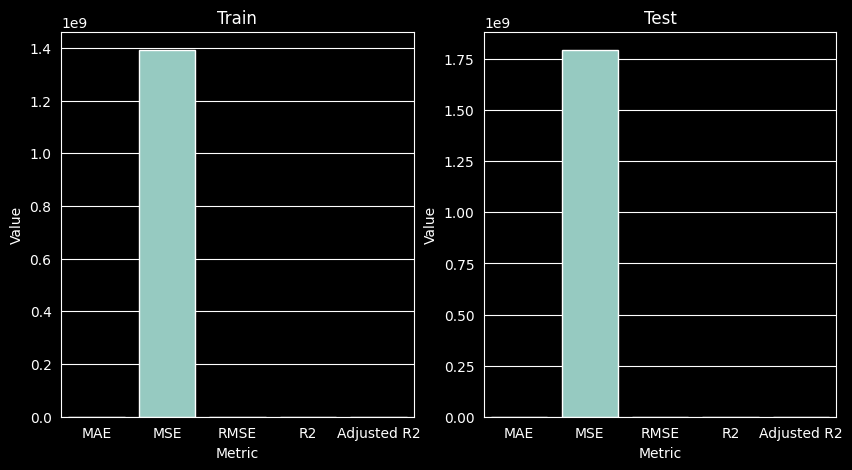

In [55]:
Ridge_pipline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge())
    ])

Ridge_pipline.set_params(**ridge_study.best_params)

_, ridge_score = judge(Ridge_pipline)

ridge_score